# Evidence-hit F1: pred vs pred0

读取 `results/evidence` 下三类文件并比较：
- `*_base_ev.json`
- `*_pred_ev.json`
- `*_pred0_ev.json`


In [192]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('results/evidence')
BASE_SUFFIX = '_base_ev.json'
PRED_SUFFIX = '_pred_ev.json'
PRED0_SUFFIX = '_pred0_ev.json'

VARIANT_SUFFIX = {
    'pred': PRED_SUFFIX,
    'pred0': PRED0_SUFFIX,
}

# pred.general 对应 base 的 General + Applicant
SECTION_MAPPING = {
    'general': ['General', 'Applicant'],
    'proposed_research': ['Proposed research'],
    'training_development': ['Training and development'],
    'sites_support': ['Sites and support'],
    'wpcc': ['Working with people and communities'],
    'application_form': ['Application Form'],
}


In [193]:
def resolve_conflicts_keep_head(text: str) -> str:
    out = []
    lines = text.splitlines()
    i = 0
    while i < len(lines):
        line = lines[i]
        if line.startswith('<<<<<<< '):
            i += 1
            while i < len(lines) and not lines[i].startswith('======='):
                out.append(lines[i])
                i += 1
            while i < len(lines) and not lines[i].startswith('>>>>>>> '):
                i += 1
            if i < len(lines) and lines[i].startswith('>>>>>>> '):
                i += 1
            continue
        out.append(line)
        i += 1
    return "\n".join(out) + ("\n" if text.endswith("\n") else "")


def load_json(path: Path):
    text = path.read_text(encoding='utf-8')
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return json.loads(resolve_conflicts_keep_head(text))


def parse_pred_obj(d: dict) -> dict:
    out = {}
    for k, v in d.items():
        if isinstance(v, str):
            try:
                out[k] = json.loads(v)
            except json.JSONDecodeError:
                out[k] = json.loads(resolve_conflicts_keep_head(v))
        else:
            out[k] = v
    return out


def base_criteria(base_obj: dict, sections: list[str]):
    rows = []

    # Format A: base[section][criterion]['used_chunk_ids']
    for sec in sections:
        sec_obj = base_obj.get(sec, {})
        if not isinstance(sec_obj, dict):
            continue
        for crit, crit_obj in sec_obj.items():
            if isinstance(crit_obj, dict) and 'used_chunk_ids' in crit_obj:
                rows.append((sec, crit, set(crit_obj.get('used_chunk_ids') or [])))

    if rows:
        return rows

    # Format B: base['used_chunk_ids'][section][criterion] = [chunk_ids]
    top_used = base_obj.get('used_chunk_ids', {})
    if isinstance(top_used, dict):
        for sec in sections:
            sec_map = top_used.get(sec, {})
            if not isinstance(sec_map, dict):
                continue
            for crit, chunk_list in sec_map.items():
                if isinstance(chunk_list, list):
                    rows.append((sec, crit, set(chunk_list)))

    return rows


def pred_criteria(pred_sec_obj: dict):
    rows = []
    for crit, crit_obj in pred_sec_obj.items():
        if isinstance(crit_obj, dict) and 'used_chunk_ids' in crit_obj:
            rows.append((crit, set(crit_obj.get('used_chunk_ids') or [])))
    return rows


def score(base_chunks: set, pred_chunks: set):
    tp = len(base_chunks & pred_chunks)
    fp = len(pred_chunks - base_chunks)
    fn = len(base_chunks - pred_chunks)
    p = tp / (tp + fp) if (tp + fp) else np.nan
    r = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (2 * p * r / (p + r)) if pd.notna(p) and pd.notna(r) and (p + r) else np.nan
    return tp, fp, fn, p, r, f1


def evaluate_variant(variant: str, suffix: str) -> pd.DataFrame:
    base_paths = {f.name.replace(BASE_SUFFIX, ''): f for f in DATA_DIR.glob(f'*{BASE_SUFFIX}')}
    pred_paths = {f.name.replace(suffix, ''): f for f in DATA_DIR.glob(f'*{suffix}')}
    case_ids = sorted(set(base_paths) & set(pred_paths))

    rows = []
    for cid in case_ids:
        base_obj = load_json(base_paths[cid])
        pred_obj = parse_pred_obj(load_json(pred_paths[cid]))

        for pred_sec, base_secs in SECTION_MAPPING.items():
            b_rows = base_criteria(base_obj, base_secs)
            p_rows = pred_criteria(pred_obj.get(pred_sec, {}))
            n = min(len(b_rows), len(p_rows))

            for i in range(n):
                b_sec, b_crit, b_chunks = b_rows[i]
                p_crit, p_chunks = p_rows[i]
                tp, fp, fn, p, r, f1 = score(b_chunks, p_chunks)
                rows.append({
                    'variant': variant,
                    'case_id': cid,
                    'pred_section': pred_sec,
                    'pair_index': i + 1,
                    'base_section': b_sec,
                    'base_criterion': b_crit,
                    'pred_criterion': p_crit,
                    'tp': tp,
                    'fp': fp,
                    'fn': fn,
                    'precision': p,
                    'recall': r,
                    'f1': f1,
                })

    return pd.DataFrame(rows)


def summarize(df: pd.DataFrame) -> pd.Series:
    tp, fp, fn = df['tp'].sum(), df['fp'].sum(), df['fn'].sum()
    p = tp / (tp + fp) if (tp + fp) else np.nan
    r = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (2 * p * r / (p + r)) if pd.notna(p) and pd.notna(r) and (p + r) else np.nan
    return pd.Series({
        'criteria_n': len(df),
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'micro_precision': p,
        'micro_recall': r,
        'micro_f1': f1,
        'macro_f1': df['f1'].mean(),
    })


In [194]:
criterion_df = pd.concat(
    [evaluate_variant(v, s) for v, s in VARIANT_SUFFIX.items()],
    ignore_index=True,
)
print('rows:', len(criterion_df))
criterion_df.head(10)


rows: 612


,variant,case_id,pred_section,pair_index,base_section,base_criterion,pred_criterion,tp,fp,fn,precision,recall,f1
0,pred,IC00001,general,1,General,common_characteristics_of_good_applications,g.1,12,7,4,0.631579,0.750000,0.685714
1,pred,IC00001,general,2,General,tell_us_why_you_need_this_award,g.2,7,1,7,0.875000,0.500000,0.636364
2,pred,IC00001,proposed_research,1,Proposed research,Quality of the Plain English Summary,pr.1,5,0,4,1.000000,0.555556,0.714286
3,pred,IC00001,proposed_research,2,Proposed research,Evidence Review Quality & Relevance,pr.2,7,0,3,1.000000,0.700000,0.823529
4,pred,IC00001,proposed_research,3,Proposed research,Research Scope & Award Appropriateness,pr.3,3,3,6,0.500000,0.333333,0.400000
5,pred,IC00001,proposed_research,4,Proposed research,Research Design & Methodological Rigor,pr.4,9,0,6,1.000000,0.600000,0.750000
6,pred,IC00001,proposed_research,5,Proposed research,"Potential Impact on Patients, Public, and Heal...",pr.5,6,0,3,1.000000,0.666667,0.800000
7,pred,IC00001,proposed_research,6,Proposed research,Engagement with People & Communities,pr.6,8,1,4,0.888889,0.666667,0.761905
8,pred,IC00001,proposed_research,7,Proposed research,Justification of Resources & Award Costs,pr.7,16,0,0,1.000000,1.000000,1.000000
9,pred,IC00001,proposed_research,8,Proposed research,Quality of Previous Research (if applicable),pr.8,6,0,3,1.000000,0.666667,0.800000


In [195]:
overall_summary = (
    criterion_df.groupby('variant', as_index=False)
    .apply(summarize, include_groups=False)
    .sort_values('variant')
    .reset_index(drop=True)
)
overall_summary


,variant,criteria_n,tp,fp,fn,micro_precision,micro_recall,micro_f1,macro_f1
0,pred,306.0,921.0,517.0,554.0,0.640473,0.624407,0.632338,0.673551
1,pred0,306.0,869.0,633.0,606.0,0.578562,0.589153,0.583809,0.660003


In [196]:
case_summary = (
    criterion_df.groupby(['variant', 'case_id'], as_index=False)
    .apply(summarize, include_groups=False)
    .sort_values(['variant', 'case_id'])
    .reset_index(drop=True)
)
case_summary[['variant','case_id','micro_f1','macro_f1']]


,variant,case_id,micro_f1,macro_f1
0,pred,IC00001,0.751880,0.775707
1,pred,IC00003,0.629630,0.700346
2,pred,IC00008,0.573290,0.613089
3,pred,IC00011,0.781065,0.801693
4,pred,IC00047,0.655502,0.657883
5,pred,IC00069,0.620690,0.662013
6,pred,IC00080,0.542587,0.638381
7,pred,IC00096,0.506849,0.534787
8,pred,IC00103,0.622222,0.640236
9,pred,IC00176,0.677596,0.731336


In [197]:
section_summary = (
    criterion_df.groupby(['variant', 'pred_section'], as_index=False)
    .agg(mean_f1=('f1','mean'))
    .sort_values(['pred_section','variant'])
)
section_summary


,variant,pred_section,mean_f1
0,pred,application_form,0.659524
6,pred0,application_form,0.819933
1,pred,general,0.667974
7,pred0,general,0.579353
2,pred,proposed_research,0.651972
8,pred0,proposed_research,0.669569
3,pred,sites_support,0.698236
9,pred0,sites_support,0.657737
4,pred,training_development,0.729201
10,pred0,training_development,0.667259


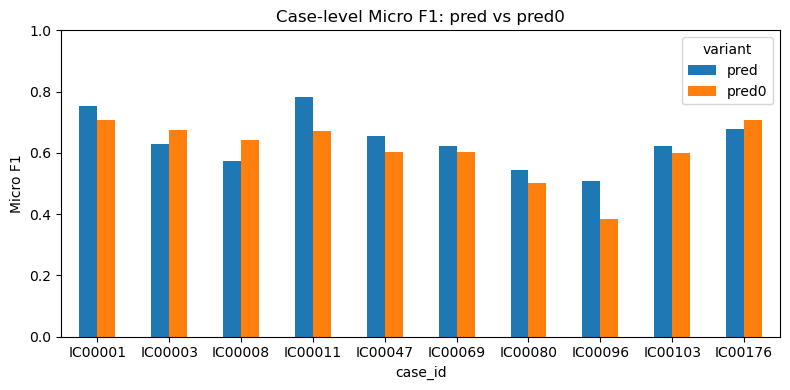

In [198]:
ax = case_summary.pivot(index='case_id', columns='variant', values='micro_f1').plot(kind='bar', figsize=(8,4))
ax.set_title('Case-level Micro F1: pred vs pred0')
ax.set_ylim(0,1)
ax.set_ylabel('Micro F1')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


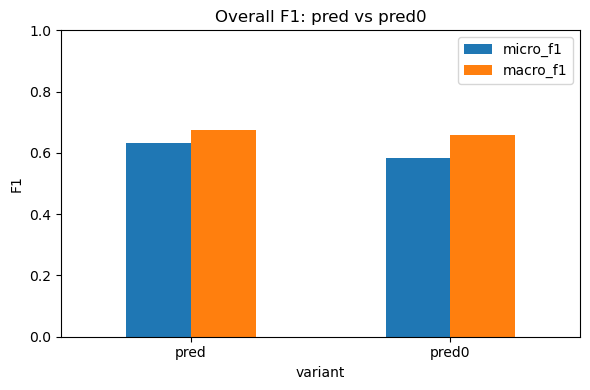

In [199]:
ax = overall_summary.set_index('variant')[['micro_f1','macro_f1']].plot(kind='bar', figsize=(6,4))
ax.set_title('Overall F1: pred vs pred0')
ax.set_ylim(0,1)
ax.set_ylabel('F1')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


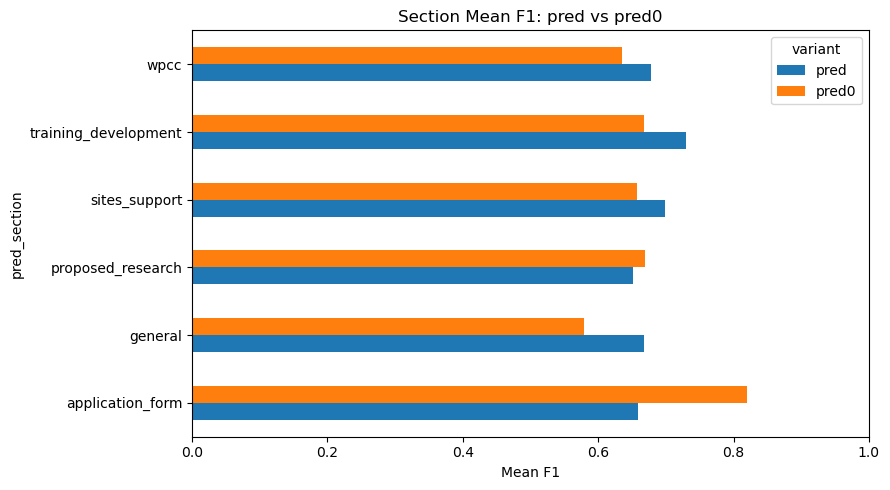

In [200]:
ax = section_summary.pivot(index='pred_section', columns='variant', values='mean_f1').plot(kind='barh', figsize=(9,5))
ax.set_title('Section Mean F1: pred vs pred0')
ax.set_xlim(0,1)
ax.set_xlabel('Mean F1')
plt.tight_layout()
plt.show()


In [201]:
# pred 相比 pred0 的总体差值
cmp = overall_summary.set_index('variant')[['micro_f1','macro_f1']]
delta = (cmp.loc['pred'] - cmp.loc['pred0']).rename('pred_minus_pred0')
delta.to_frame()


,pred_minus_pred0
micro_f1,0.048529
macro_f1,0.013548
